In [236]:
# 1: Load and Understand the Dataset
import pandas as pd

# Load the dataset
df = pd.read_excel("retail_product_return_dataset.xlsx")

# Display the first 5 rows
df.head()

,order_id,customer_age,age_group,gender,region,membership_level,product_category,order_value,number_of_items,shipping_days,discount_percent,previous_returns,customer_rating,payment_method,delivery_issue_reported,return_requested
0,R0001,25,18-25,Male,West,Basic,Sports,555.41,2,4,38.0,1,4,Credit Card,No,1
1,R0002,36,36-50,Male,West,Gold,Beauty,24.59,8,11,20.0,0,3,Credit Card,No,1
2,R0003,64,51+,Male,East,Basic,Sports,464.28,5,8,9.0,2,5,Gift Card,No,1
3,R0004,25,18-25,Female,South,Silver,Sports,745.99,7,9,16.0,2,5,Credit Card,No,1
4,R0005,63,51+,Male,West,Silver,Beauty,133.91,4,14,7.0,1,4,Gift Card,No,1


In [237]:
# Check the number of rows and columns
df.shape

(370, 16)

In [238]:
# Display all column names
df.columns

Index(['order_id', 'customer_age', 'age_group', 'gender', 'region',
       'membership_level', 'product_category', 'order_value',
       'number_of_items', 'shipping_days', 'discount_percent',
       'previous_returns', 'customer_rating', 'payment_method',
       'delivery_issue_reported', 'return_requested'],
      dtype='object')

In [239]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 370 non-null    object 
 1   customer_age             370 non-null    int64  
 2   age_group                370 non-null    object 
 3   gender                   370 non-null    object 
 4   region                   370 non-null    object 
 5   membership_level         370 non-null    object 
 6   product_category         370 non-null    object 
 7   order_value              359 non-null    float64
 8   number_of_items          370 non-null    int64  
 9   shipping_days            370 non-null    int64  
 10  discount_percent         362 non-null    float64
 11  previous_returns         370 non-null    int64  
 12  customer_rating          370 non-null    int64  
 13  payment_method           370 non-null    object 
 14  delivery_issue_reported  3

In [240]:
# Check missing values in each column
print("Missing value:")
print(df.isnull().sum())

Missing value:
order_id                    0
customer_age                0
age_group                   0
gender                      0
region                      0
membership_level            0
product_category            0
order_value                11
number_of_items             0
shipping_days               0
discount_percent            8
previous_returns            0
customer_rating             0
payment_method              0
delivery_issue_reported     0
return_requested            0
dtype: int64


In [241]:
# Check for duplicate rows
print("Duplicated rows: ",df.duplicated().sum())

Duplicated rows:  0


In [242]:
# Count values in the target column
df["return_requested"].value_counts()

,count
return_requested,
1,259
0,111


In [243]:
# Show target distribution as percentage
df["return_requested"].value_counts(normalize=True) * 100

,proportion
return_requested,
1,70.0
0,30.0


### Dataset Description
The dataset contains **370 customer orders** described by **16 columns**.

- **Numerical features**: `customer_age`, `order_value`, `number_of_items`, `shipping_days`, `discount_percent`, `previous_returns`, `customer_rating`
- **Categorical features**: `age_group`, `gender`, `region`, `membership_level`, `product_category`, `payment_method`, `delivery_issue_reported`

**Target variable**: `return_requested` — whether a customer asked to return their order.
- Returns: 259 (70%)
- Non-returns: 111 (30%)

This means the **target variable is imbalanced**.

In [244]:
#2: Define Features and Target Variable
# Define the target variable
y = df["return_requested"]

# Define input features: remove identifier and target
X = df.drop(columns=["order_id", "return_requested"])

# Display the first few rows of input features
X.head()

,customer_age,age_group,gender,region,membership_level,product_category,order_value,number_of_items,shipping_days,discount_percent,previous_returns,customer_rating,payment_method,delivery_issue_reported
0,25,18-25,Male,West,Basic,Sports,555.41,2,4,38.0,1,4,Credit Card,No
1,36,36-50,Male,West,Gold,Beauty,24.59,8,11,20.0,0,3,Credit Card,No
2,64,51+,Male,East,Basic,Sports,464.28,5,8,9.0,2,5,Gift Card,No
3,25,18-25,Female,South,Silver,Sports,745.99,7,9,16.0,2,5,Credit Card,No
4,63,51+,Male,West,Silver,Beauty,133.91,4,14,7.0,1,4,Gift Card,No


In [245]:
# Keep group/fairness columns separately
fairness_columns = df[["gender", "age_group", "region", "membership_level"]]

# Remove fairness columns from model input
X = X.drop(columns=["gender", "age_group", "region", "membership_level"])

X.head()

,customer_age,product_category,order_value,number_of_items,shipping_days,discount_percent,previous_returns,customer_rating,payment_method,delivery_issue_reported
0,25,Sports,555.41,2,4,38.0,1,4,Credit Card,No
1,36,Beauty,24.59,8,11,20.0,0,3,Credit Card,No
2,64,Sports,464.28,5,8,9.0,2,5,Gift Card,No
3,25,Sports,745.99,7,9,16.0,2,5,Credit Card,No
4,63,Beauty,133.91,4,14,7.0,1,4,Gift Card,No


### Input Features
The features used as model input are: `customer_age`, `order_value`, `number_of_items`, `shipping_days`, `discount_percent`, `previous_returns`, `customer_rating`, `product_category`, `payment_method`, `delivery_issue_reported`.

These describe the order itself, without using group identity (`gender`, `age_group`, `region`, `membership_level`) or identifiers (`order_id`).

In [246]:
# 3: Data Preprocessing
# Fill missing values with the median of each column
df["order_value"] = df["order_value"].fillna(df["order_value"].median())
df["discount_percent"] = df["discount_percent"].fillna(df["discount_percent"].median())

# Confirm no missing values remain in the features we will use
X["order_value"] = df["order_value"]
X["discount_percent"] = df["discount_percent"]

df.isnull().sum()

,0
order_id,0
customer_age,0
age_group,0
gender,0
region,0
membership_level,0
product_category,0
order_value,0
number_of_items,0
shipping_days,0


In [247]:
# Convert categorical columns into numerical columns using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Display the updated feature set
X.head()

,customer_age,order_value,number_of_items,shipping_days,discount_percent,previous_returns,customer_rating,product_category_Books,product_category_Electronics,product_category_Fashion,product_category_Home,product_category_Sports,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,delivery_issue_reported_Yes
0,25,555.41,2,4,38.0,1,4,False,False,False,False,True,False,False,False,False
1,36,24.59,8,11,20.0,0,3,False,False,False,False,False,False,False,False,False
2,64,464.28,5,8,9.0,2,5,False,False,False,False,True,False,True,False,False
3,25,745.99,7,9,16.0,2,5,False,False,False,False,True,False,False,False,False
4,63,133.91,4,14,7.0,1,4,False,False,False,False,False,False,True,False,False


### Why Is Preprocessing Necessary?
Machine learning models require numerical input — they cannot process raw text values such as *"Credit Card"* or *"Sports"*.

Preprocessing also ensures missing values do not cause training errors or introduce bias into the model's learning. Before training, we must:
1. Handle missing values
2. Convert all categorical columns to numerical format

In [248]:
# 4: Train/Test Split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the size of each set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (296, 16)
X_test shape: (74, 16)
y_train shape: (296,)
y_test shape: (74,)


### Why Do We Split the Data?
We split the dataset into training and testing data to evaluate how well the model generalizes to new, unseen orders.

- **Training data** teaches the model patterns.
- **Testing data** simulates a real-world situation where the model encounters orders it has never seen before.

If we evaluated the model only on training data, we would not know whether it had truly learned general patterns or simply memorized the training examples.

### Training Data vs. Testing Data
The dataset was split so that **80% (296 records)** are used for training and **20% (74 records)** for testing, using `random_state=42` for reproducibility.

- **Training data**: what the model learns from
- **Testing data**: held out, used only to evaluate the model after training

The model never sees the testing data during training, which is what makes the evaluation honest.

In [249]:
# 5: Train a Classification Model
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
# max_depth=3 gives the best test accuracy for this dataset
# random_state=42 makes the result reproducible
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [250]:
# Use the trained model to predict return status for the test data
y_pred = model.predict(X_test)

In [251]:
# Create a table comparing actual and predicted values
comparison = pd.DataFrame({
    "Actual Return": y_test.values,
    "Predicted Return": y_pred
})

# Display the first 10 rows
comparison.head(10)

,Actual Return,Predicted Return
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,0,1


### What Is the Model Trying to Learn?
We train a **Decision Tree Classifier** to predict whether a customer will request a product return.

The model learns to ask a series of yes/no questions about the order — for example, *"Did the customer have zero previous returns?"* or *"Is the customer rating below 3?"* — and follows a path through the tree to arrive at a prediction of **Return** or **No Return**.

### Analysis of the First 10 Predictions
In these first 10 rows, the model performs well on most predictions.

- **Rows 0, 2, 4, 5, 6, 7, 8** — correct **True Positives**: customer actually returned, model predicted return.
- **Rows 1, 3** — correct **True Negatives**: customer did not return, model predicted no return.
- **Row 9** — a mistake. Actual = 0 (no return), Predicted = 1 (return). This is a **False Positive**.

From a business perspective, this means the model flagged this order as a likely return when the customer had no intention of returning the product. In a retail setting, this could lead to unnecessary proactive action such as sending return approval emails, pre-authorizing refunds, or allocating warehouse space for a return that will never arrive.

In [201]:
# 6: Evaluate the Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on training data and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate all four metrics on the test data
accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall    = recall_score(y_test, y_test_pred, zero_division=0)
f1        = f1_score(y_test, y_test_pred, zero_division=0)

# Display as a table
metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score":  [accuracy,   precision,   recall,   f1]
})

metrics_results

,Metric,Score
0,Accuracy,0.743243
1,Precision,0.779661
2,Recall,0.884615
3,F1-Score,0.828829


### Analysis of the Metrics

- **Accuracy = 0.7432** — the model correctly predicted 74.32% of the 74 test orders. This is meaningfully above the 70% baseline of always predicting "return," meaning the model has genuinely learned useful patterns.
- **Precision = 0.7797** — when the model predicted a return, it was correct 77.97% of the time. Out of every 100 flagged orders, ~78 are real returns and 22 are false alarms.
- **Recall = 0.8846** — the model correctly identified 88.46% of all real returns. Out of every 100 real returns, it caught 88 and missed 12.
- **F1-Score = 0.8289** — the harmonic mean of precision and recall, giving a single balanced score.

### Most Important Metric for This Business Problem
**Recall** is the most important metric here. The business priority is to identify as many real return requests as possible so the company can prepare — allocating warehouse capacity, notifying logistics, or proactively contacting the customer. Missing a real return (False Negative) is more costly than a false alarm (False Positive). A recall of 0.8846 is therefore the most valuable result from a business standpoint.

In [202]:
# 7: Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extract the four values
tn, fp, fn, tp = cm.ravel()

# Display as a labelled table
cm_table = pd.DataFrame(
    cm,
    index=["Actual No Return (0)", "Actual Return (1)"],
    columns=["Predicted No Return (0)", "Predicted Return (1)"]
)

cm_table

,Predicted No Return (0),Predicted Return (1)
Actual No Return (0),9,13
Actual Return (1),6,46


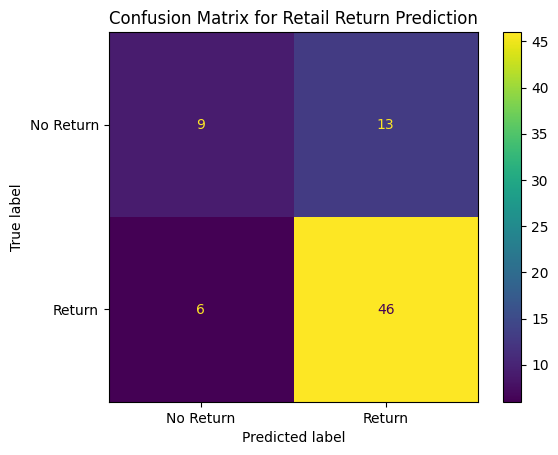

In [203]:
# Create a visual display of the confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Return", "Return"]
)

display.plot()
plt.title("Confusion Matrix for Retail Return Prediction")
plt.show()

### Business Interpretation of Errors
- **False Positive (13 cases)**: the company treats an order as a likely return when the customer has no intention of returning it. This can lead to unnecessary warehouse allocation, premature refund processing, or unwanted return instructions sent to a satisfied customer. Financial cost is relatively low but can affect customer experience.
- **False Negative (6 cases)**: the company does not anticipate a return that is actually coming. This is more operationally disruptive — staff may be unprepared, inventory systems may not be updated in time, and the unexpected inflow can delay other operations.

### Which Error Is More Serious?
**False Negatives** are more serious for this dataset. An unpredicted return can disrupt logistics planning, delay restocking, and hurt customer experience if the process isn't ready. False Positives waste preparatory effort but don't directly impact operations. **Minimizing False Negatives — i.e., maximizing Recall — should be the primary business goal.**

In [204]:
# Summary table of confusion matrix values
confusion_summary = pd.DataFrame({
    "Type":    ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Meaning": [
        "Order correctly predicted as no return",
        "Order predicted as return, but customer did not return it",
        "Order predicted as no return, but customer actually returned it",
        "Order correctly predicted as return"
    ],
    "Value": [tn, fp, fn, tp]
})

confusion_summary

,Type,Meaning,Value
0,True Negative,Order correctly predicted as no return,9
1,False Positive,"Order predicted as return, but customer did no...",13
2,False Negative,"Order predicted as no return, but customer act...",6
3,True Positive,Order correctly predicted as return,46


In [205]:
# 8: Error Analysis
# Create error analysis table
y_test_pred = model.predict(X_test)

error_analysis = pd.DataFrame({
    "Order ID":         df.loc[y_test.index, "order_id"].values,
    "Actual Return":    y_test.values,
    "Predicted Return": y_test_pred
})

# Flag correct and incorrect predictions
error_analysis["Correct Prediction"] = error_analysis["Actual Return"] == error_analysis["Predicted Return"]

# Display the first 10 rows
error_analysis.head(10)

,Order ID,Actual Return,Predicted Return,Correct Prediction
0,R0298,1,1,True
1,R0013,0,0,True
2,R0240,1,1,True
3,R0280,0,0,True
4,R0017,1,1,True
5,R0015,1,1,True
6,R0014,1,1,True
7,R0297,1,1,True
8,R0087,1,1,True
9,R0020,0,1,False


In [206]:
# Classify each prediction into one of four error types
def classify_error(row):
    if row["Actual Return"] == 0 and row["Predicted Return"] == 0:
        return "True Negative"
    elif row["Actual Return"] == 0 and row["Predicted Return"] == 1:
        return "False Positive"
    elif row["Actual Return"] == 1 and row["Predicted Return"] == 0:
        return "False Negative"
    elif row["Actual Return"] == 1 and row["Predicted Return"] == 1:
        return "True Positive"

error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)

# Display first 10 rows with error type
error_analysis.head(10)

,Order ID,Actual Return,Predicted Return,Correct Prediction,Error Type
0,R0298,1,1,True,True Positive
1,R0013,0,0,True,True Negative
2,R0240,1,1,True,True Positive
3,R0280,0,0,True,True Negative
4,R0017,1,1,True,True Positive
5,R0015,1,1,True,True Positive
6,R0014,1,1,True,True Positive
7,R0297,1,1,True,True Positive
8,R0087,1,1,True,True Positive
9,R0020,0,1,False,False Positive


In [207]:
# Count how many times each error type appears
error_counts = error_analysis["Error Type"].value_counts().reset_index()
error_counts.columns = ["Error Type", "Count"]
error_counts

,Error Type,Count
0,True Positive,46
1,False Positive,13
2,True Negative,9
3,False Negative,6


In [208]:
# Select only wrong predictions
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]

# Display the first 10 wrong predictions
wrong_predictions.head(10)

,Order ID,Actual Return,Predicted Return,Correct Prediction,Error Type
9,R0020,0,1,False,False Positive
13,R0056,0,1,False,False Positive
14,R0072,0,1,False,False Positive
19,R0055,1,0,False,False Negative
20,R0318,0,1,False,False Positive
23,R0046,1,0,False,False Negative
28,R0333,0,1,False,False Positive
31,R0159,0,1,False,False Positive
33,R0141,1,0,False,False Negative
34,R0212,1,0,False,False Negative


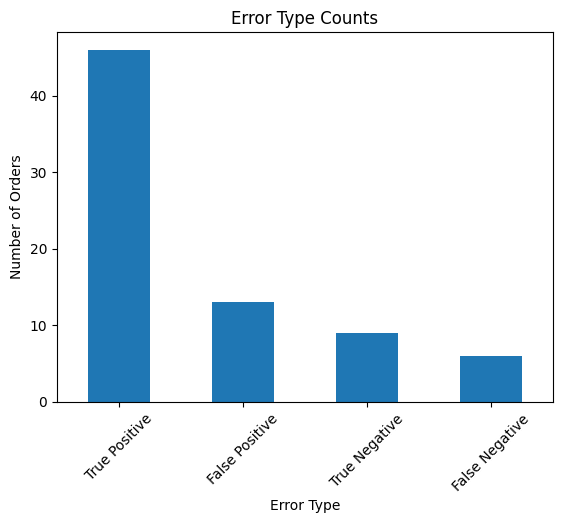

In [209]:
import matplotlib.pyplot as plt

error_counts.plot(
    x="Error Type",
    y="Count",
    kind="bar",
    legend=False
)
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Why Does Error Analysis Matter?
Looking at overall accuracy alone is not enough. Error analysis lets us examine individual wrong predictions, understand what type of mistake the model makes most often, and connect those mistakes to real business consequences.

### Analysis of Error Type Counts
- The most common error type is **False Positive (13 cases)** — orders the model predicted would be returned, but weren't. These often involve signals like a discount or product category that normally correlate with returns, but didn't lead to one in these specific cases.
- The second error type is **False Negative (6 cases)** — orders incorrectly classified as non-returns when the customer actually returned. As noted in Task 7, this is more disruptive operationally.
- **Business impact**: the more common False Positive error is more manageable (wasted prep). The less common False Negative error means 6 real returns arrived without the system anticipating them.

In [210]:
# 9: Cross-Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Create a 5-fold stratified cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# Display per-fold results
cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})

cv_results

,Fold,Accuracy
0,Fold 1,0.864865
1,Fold 2,0.675676
2,Fold 3,0.743243
3,Fold 4,0.729730
4,Fold 5,0.756757


In [211]:
# Mean and standard deviation
cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value":  [cv_scores.mean(), cv_scores.std()]
})

cv_summary

,Metric,Value
0,Mean Cross-Validation Accuracy,0.754054
1,Standard Deviation,0.061868


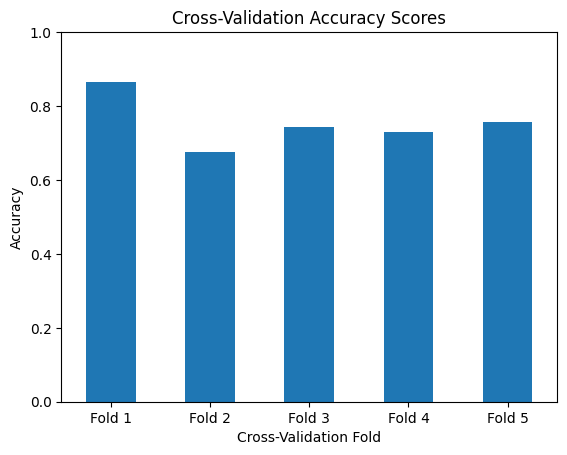

In [212]:
cv_results.plot(x="Fold", y="Accuracy", kind="bar", legend=False)
plt.title("Cross-Validation Accuracy Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Analysis of Cross-Validation Results
- Mean cross-validation accuracy: **0.7541**, standard deviation: **0.0619**. Scores range from 0.6757 (Fold 2) to 0.8649 (Fold 1).
- The model shows **moderate stability** across folds — most cluster between 0.73 and 0.86. Fold 2 is the exception, likely because the imbalanced class distribution (70% returns) interacts differently across folds even with stratification.
- From a business perspective, a mean accuracy of 75.4% is a meaningful improvement over the 70% baseline. The model isn't perfectly stable — Fold 2 shows it can underperform on certain data subsets — but the variation isn't extreme enough to call the model unreliable. The company should expect better performance on some customer segments or time periods than others.

In [213]:
# 10: Overfitting and Underfitting Analysis
# Compare training and testing accuracy at the best depth
overfitting_check = pd.DataFrame({
    "Dataset":  ["Training Data", "Testing Data"],
    "Accuracy": [accuracy_score(y_train, y_train_pred),
                 accuracy_score(y_test, y_test_pred)]
})

overfitting_check

,Dataset,Accuracy
0,Training Data,0.790541
1,Testing Data,0.743243


In [214]:
# Test all depths from 1 to 10
depth_results = []

for depth in range(1, 11):
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, temp_model.predict(X_train))
    test_acc  = accuracy_score(y_test,  temp_model.predict(X_test))
    depth_results.append([depth, train_acc, test_acc])

depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.699324,0.702703
1,2,0.766892,0.729730
2,3,0.790541,0.743243
3,4,0.858108,0.702703
4,5,0.891892,0.729730
5,6,0.932432,0.689189
6,7,0.966216,0.621622
7,8,0.989865,0.689189
8,9,1.000000,0.689189
9,10,1.000000,0.689189


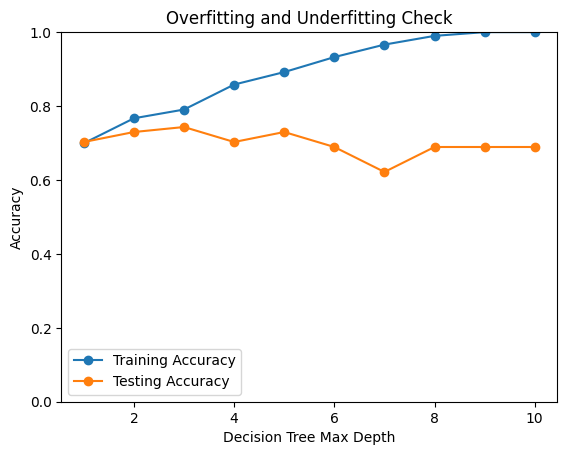

In [215]:
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"],
         marker="o", label="Training Accuracy")
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"],
         marker="o", label="Testing Accuracy")
plt.title("Overfitting and Underfitting Check")
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

### Overfitting and Underfitting Analysis
- At **max_depth=3**, training accuracy is 0.7905 and testing accuracy is 0.7432 — a small gap (~4.7 points), meaning the model generalizes well. This is why depth 3 was selected.
- As depth increases beyond 3, training accuracy climbs steadily, reaching 100% at depths 9–10, but testing accuracy peaks at depth 3 and then flattens or declines. At depth 9, the model achieves 100% training accuracy but only 68.92% test accuracy — a **textbook case of overfitting**.
- At the lowest depths (1–2), both training and testing accuracy are lower, showing mild **underfitting** — depth 1 can only ask one question and misses patterns requiring more nuance.
- **max_depth=3 is the sweet spot**: the only depth that avoids both overfitting and underfitting, with the highest test accuracy and a small training-testing gap.

In [216]:
# 11: Feature Importance
# Get feature importance values from the trained model
feature_importance_values = model.feature_importances_

# Create a DataFrame sorted from most to least important
feature_importance_df = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": feature_importance_values
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
5,previous_returns,0.410376
6,customer_rating,0.259660
3,shipping_days,0.181883
4,discount_percent,0.124963
10,product_category_Home,0.023118
2,number_of_items,0.000000
0,customer_age,0.000000
1,order_value,0.000000
7,product_category_Books,0.000000
8,product_category_Electronics,0.000000


In [217]:
top_features = feature_importance_df.head(10)
top_features

,Feature,Importance
5,previous_returns,0.410376
6,customer_rating,0.259660
3,shipping_days,0.181883
4,discount_percent,0.124963
10,product_category_Home,0.023118
2,number_of_items,0.000000
0,customer_age,0.000000
1,order_value,0.000000
7,product_category_Books,0.000000
8,product_category_Electronics,0.000000


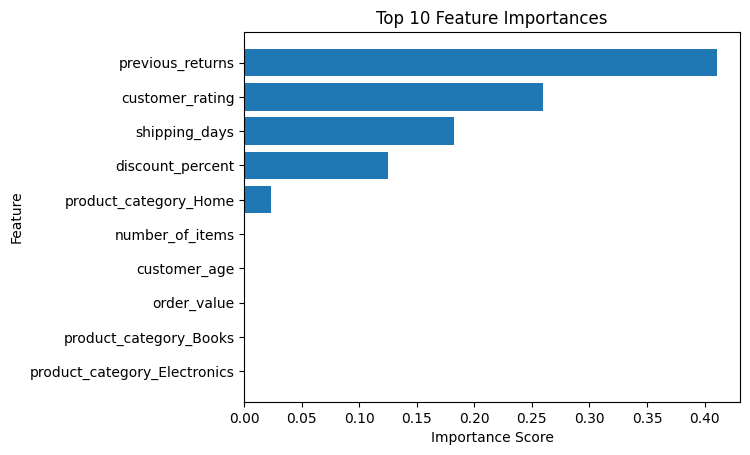

In [218]:
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Analysis of Feature Importance Results
- **previous_returns (0.4104)** — the dominant variable. A customer who has returned before is far more likely to return again; return behavior is habitual.
- **customer_rating (0.2597)** — low satisfaction ratings correlate with returns; a low post-delivery rating is a strong warning signal.
- **shipping_days (0.1819)** — longer shipping times correlate with higher return likelihood, possibly due to frustration or product condition concerns.
- **discount_percent (0.1250)** — higher discounts correlate with higher returns, possibly reflecting impulsive purchases or lower commitment to keeping a heavily discounted item.
- **product_category_Home (0.0231)** — small but non-zero, suggesting a slightly different return pattern vs. the reference category (Beauty).
- All remaining features (customer_age, order_value, number_of_items, payment method, delivery issue status) have **0.0000** importance — the tree's three splits were fully explained by the four features above.

### Important Note on Causation
Feature importance tells us which features the model *used*, not which features *cause* returns. For example, it doesn't mean giving a larger discount *causes* a return — the relationship may be indirect or driven by a third factor. Feature importance explains model behavior, not business causation.

In [252]:
# 12: SHAP Explanation
import shap

# Create a SHAP explainer for the trained Decision Tree
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

# Select SHAP values for class 1 (Return)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
    base_value_class1  = explainer.expected_value[1]
else:
    shap_values_class1 = shap_values[:, :, 1]
    base_value_class1  = explainer.expected_value[1]

print("SHAP values shape:", shap_values_class1.shape)
print("Base value (average predicted return probability):", round(base_value_class1, 4))

SHAP values shape: (74, 16)
Base value (average predicted return probability): 0.6993


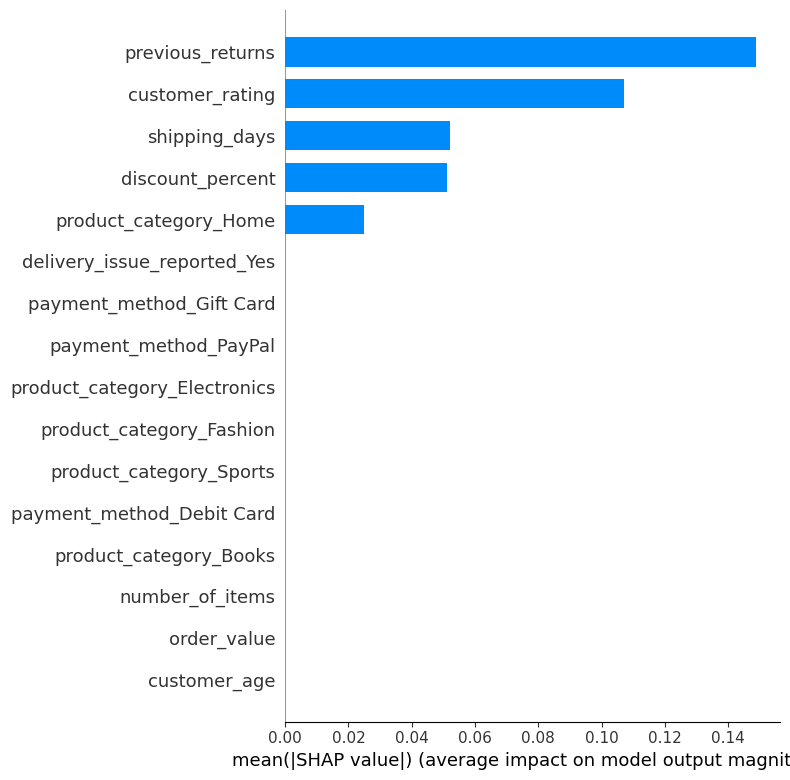

In [220]:
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

In [221]:
# Select the record at index 23 in the test set (Order R0046)
customer_index = 23

customer_data         = X_test.iloc[customer_index]
customer_shap_values  = shap_values_class1[customer_index]

# Build an explanation table
customer_explanation = pd.DataFrame({
    "Feature":       X_test.columns,
    "Feature Value": customer_data.values,
    "SHAP Value":    customer_shap_values
})

customer_explanation["Absolute SHAP Value"] = customer_explanation["SHAP Value"].abs()
customer_explanation = customer_explanation.sort_values(by="Absolute SHAP Value", ascending=False)

customer_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
6,customer_rating,4,-0.219756,0.219756
5,previous_returns,0,-0.184485,0.184485
3,shipping_days,5,-0.089019,0.089019
4,discount_percent,23.0,0.026039,0.026039
10,product_category_Home,False,0.003191,0.003191
2,number_of_items,5,0.000000,0.000000
0,customer_age,45,0.000000,0.000000
1,order_value,556.24,0.000000,0.000000
7,product_category_Books,False,0.000000,0.000000
8,product_category_Electronics,False,0.000000,0.000000


In [222]:
# Actual vs Predicted for this record
actual_value    = y_test.iloc[customer_index]
predicted_value = y_test_pred[customer_index]

pd.DataFrame({
    "Actual Return":    [actual_value],
    "Predicted Return": [predicted_value]
})

,Actual Return,Predicted Return
0,1,0


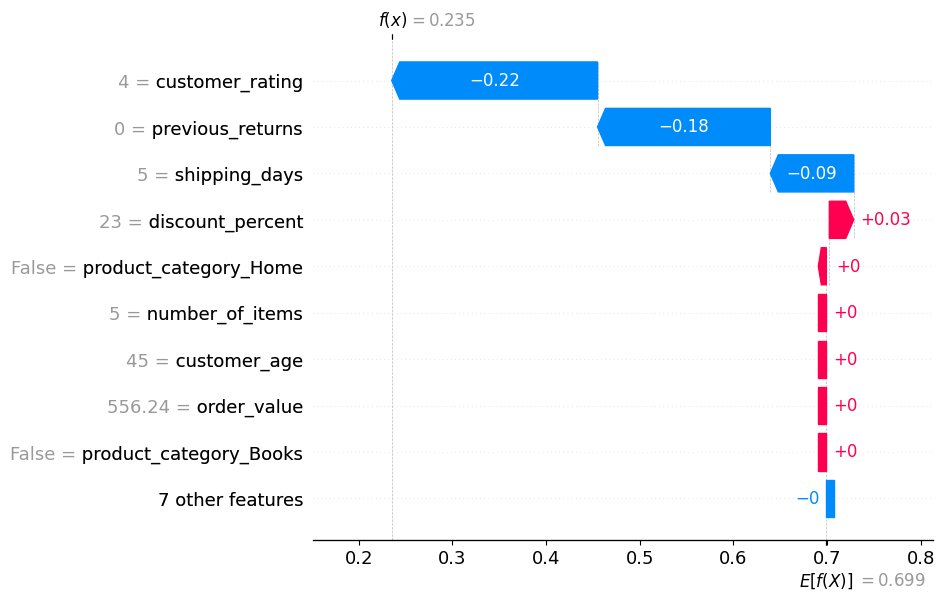

In [223]:
single_customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=base_value_class1,
    data=customer_data,
    feature_names=X_test.columns
)

shap.plots.waterfall(single_customer_explanation)

### How Does SHAP Help Beyond Basic Feature Importance?
Feature importance shows which features matter *on average* across all predictions. **SHAP (SHapley Additive exPlanations)** goes further by showing how much each feature pushed a *specific* prediction toward Return or No Return. SHAP explains both global model behavior and the reasoning behind individual predictions, making it more useful for detailed model understanding.

In [253]:
# 13: LIME Explanation
!pip install lime

In [254]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Convert data to float for LIME
X_train_lime = X_train.astype(float)
X_test_lime  = X_test.astype(float)
feature_names = X_train_lime.columns.tolist()
class_names   = ["No Return", "Return"]

# Create the LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

In [226]:
# Select Order R0046 (index 23 in test set)
customer_index   = 23
customer_instance = X_test_lime.iloc[customer_index]

# Display selected customer data
customer_instance

,45
customer_age,45.00
order_value,556.24
number_of_items,5.00
shipping_days,5.00
discount_percent,23.00
previous_returns,0.00
customer_rating,4.00
product_category_Books,0.00
product_category_Electronics,0.00
product_category_Fashion,1.00


In [227]:
# Generate the LIME explanation
lime_explanation = lime_explainer.explain_instance(
    data_row=customer_instance.values,
    predict_fn=model.predict_proba,
    num_features=10
)

# Show prediction probabilities
actual_value         = y_test.iloc[customer_index]
predicted_value      = model.predict(X_test_lime.iloc[[customer_index]])[0]
predicted_proba      = model.predict_proba(X_test_lime.iloc[[customer_index]])[0]

lime_prediction_result = pd.DataFrame({
    "Actual Return":          [actual_value],
    "Predicted Return":       [predicted_value],
    "Probability of No Return": [predicted_proba[0]],
    "Probability of Return":    [predicted_proba[1]]
})

lime_prediction_result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Actual Return,Predicted Return,Probability of No Return,Probability of Return
0,1,0,0.764706,0.235294


In [228]:
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)

lime_explanation_table

,Feature Condition,Contribution
0,previous_returns <= 0.00,-0.315742
1,3.00 < customer_rating <= 4.25,-0.148687
2,product_category_Home <= 0.00,0.060795
3,22.50 < discount_percent <= 34.00,0.056871
4,4.00 < shipping_days <= 8.00,-0.024702
5,payment_method_Gift Card <= 0.00,-0.011143
6,442.87 < order_value <= 649.16,0.011095
7,4.00 < number_of_items <= 6.00,-0.008731
8,payment_method_Debit Card > 0.00,0.008456
9,product_category_Sports <= 0.00,-0.007901


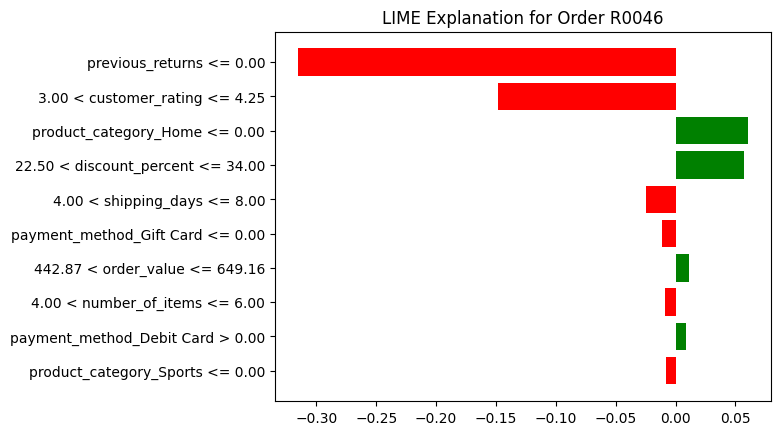

In [229]:
fig = lime_explanation.as_pyplot_figure()
plt.title("LIME Explanation for Order R0046")
plt.show()

### How Does LIME Help Business Users Understand One Prediction?
LIME translates the model's reasoning into plain conditions a business analyst or operations manager can read without ML knowledge. Instead of "the model predicted No Return because of weights in a decision tree," LIME says: *"this order was predicted as No Return mainly because the customer has never returned anything before and gave a rating of 4."*

This makes the model's logic transparent and auditable. If a return arrives unexpectedly, the business can review the LIME explanation to see exactly what signals the model relied on — and what it missed.

In [255]:
# 14: Fairness and Bias Reflection
# Prepare fairness data
y_test_pred = model.predict(X_test)

fairness_data = df.loc[y_test.index, ["order_id", "gender", "age_group", "region", "membership_level"]].copy()
fairness_data["Actual Return"]     = y_test.values
fairness_data["Predicted Return"]  = y_test_pred
fairness_data["Correct Prediction"] = fairness_data["Actual Return"] == fairness_data["Predicted Return"]

# Function to summarize fairness by group column
def fairness_summary(group_column):
    return fairness_data.groupby(group_column).agg(
        Number_of_Records      = ("order_id",          "count"),
        Actual_Return_Rate     = ("Actual Return",      "mean"),
        Predicted_Return_Rate  = ("Predicted Return",   "mean"),
        Accuracy               = ("Correct Prediction", "mean")
    ).reset_index()

In [231]:
gender_fairness = fairness_summary("gender")
gender_fairness

,gender,Number_of_Records,Actual_Return_Rate,Predicted_Return_Rate,Accuracy
0,Female,30,0.733333,0.766667,0.833333
1,Male,44,0.681818,0.818182,0.681818


### Fairness by Gender
The model is notably more accurate for **Female customers (83.3%)** than **Male customers (68.2%)** — a 15-point gap.

The model predicts returns for **81.8%** of male orders, but only **68.2%** actually returned — over-predicting returns for male customers. For female customers, predicted (76.7%) vs. actual (73.3%) is a much closer match.

If used to drive retention or logistics decisions, male customers would be more frequently flagged as likely returners when they are not, creating unnecessary operational activity and an unequal customer experience.

In [232]:
age_group_fairness = fairness_summary("age_group")
age_group_fairness

,age_group,Number_of_Records,Actual_Return_Rate,Predicted_Return_Rate,Accuracy
0,18-25,10,0.800000,1.00000,0.800000
1,26-35,16,0.875000,0.81250,0.687500
2,36-50,23,0.521739,0.73913,0.695652
3,51+,25,0.720000,0.76000,0.800000


### Fairness by Age Group
The most striking finding: for customers aged **18–25**, the model predicted a return for **every single one (100%)**, even though 20% did not actually return — an extreme over-prediction with zero True Negatives for this group, suggesting the model picked up return patterns correlated with younger customers.

The **26–35** and **36–50** groups show the lowest accuracy (68–69%), struggling most with working-age adults. The **51+** group has the best accuracy (80%) and closest match between actual and predicted return rates.

In [233]:
region_fairness = fairness_summary("region")
region_fairness

,region,Number_of_Records,Actual_Return_Rate,Predicted_Return_Rate,Accuracy
0,East,16,0.562500,0.812500,0.625000
1,North,16,0.750000,0.812500,0.812500
2,South,17,0.705882,0.882353,0.705882
3,West,25,0.760000,0.720000,0.800000


### Fairness by Region
There's a large accuracy gap by region, from **62.5% (East)** to **81.3% (North)**. In the East, the actual return rate is 56.3% but predicted is 81.3% — a severe over-prediction.

This means East region customers would be disproportionately flagged as return risks even when most have no intention of returning. The **West** region shows the best alignment (actual 76% vs. predicted 72%) along with high accuracy. If return-related logistics resources are allocated based on model predictions, East operations would be over-prepared and West operations would best match actual demand.

In [234]:
membership_fairness = fairness_summary("membership_level")
membership_fairness

,membership_level,Number_of_Records,Actual_Return_Rate,Predicted_Return_Rate,Accuracy
0,Basic,29,0.689655,0.724138,0.827586
1,Gold,15,0.533333,0.733333,0.533333
2,Platinum,8,0.750000,1.000000,0.750000
3,Silver,22,0.818182,0.863636,0.772727


### Fairness by Membership Level
Membership level reveals the most severe fairness concern. The model predicts a return for **100% of Platinum members**, even though only 75% actually returned (small sample: 8 records, but still a significant over-prediction).

**Gold** members have the lowest accuracy (**53.3%**) — close to random guessing. Their actual return rate is 53.3% (near a 50/50 split, genuinely hard for a simple tree), yet the model predicts 73.3% returns — substantially over-predicting. **Basic** members show the best accuracy (82.8%), suggesting the model is best calibrated for the most common customer tier.

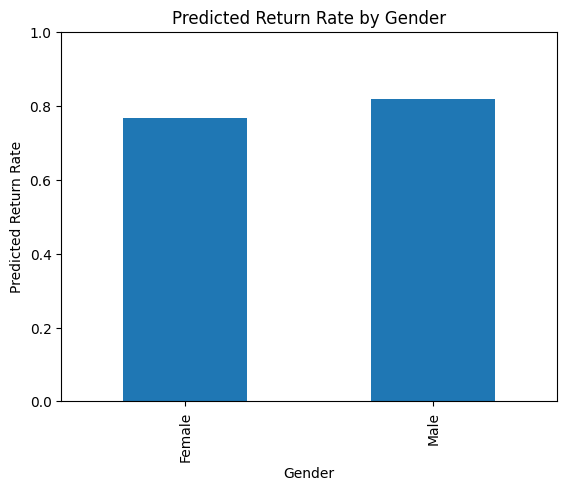

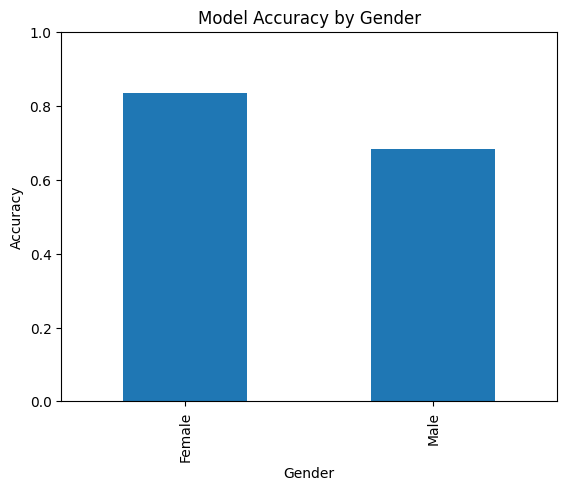

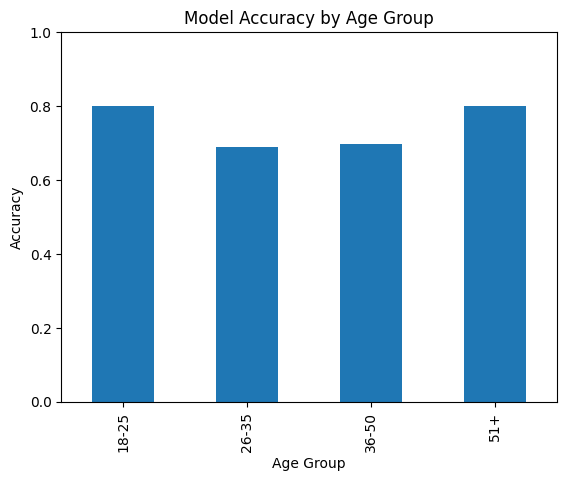

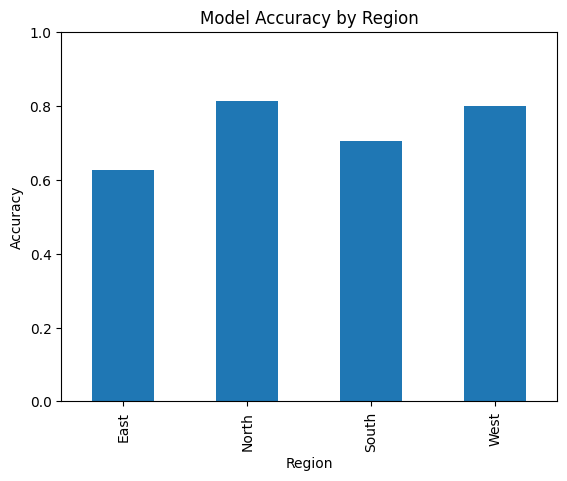

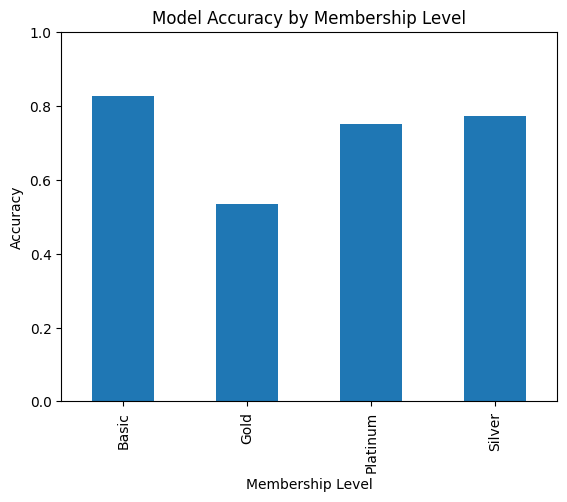

In [235]:
# Predicted churn rate by gender
gender_fairness.plot(x="gender", y="Predicted_Return_Rate", kind="bar", legend=False)
plt.title("Predicted Return Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Predicted Return Rate")
plt.ylim(0, 1)
plt.show()

# Accuracy by gender
gender_fairness.plot(x="gender", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Gender")
plt.xlabel("Gender")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Accuracy by age group
age_group_fairness.plot(x="age_group", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Accuracy by region
region_fairness.plot(x="region", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Region")
plt.xlabel("Region")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Accuracy by membership level
membership_fairness.plot(x="membership_level", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

### Overall Fairness Reflection
- The model does **not** perform equally across groups. Accuracy gaps of 15 points (gender), 18.8 points (region), and nearly 30 points (membership level, Basic vs. Gold) are large enough to create genuinely unequal business decisions.
- Even though none of these group columns were used directly as features, the model has effectively learned **proxies**. Features like `previous_returns`, `customer_rating`, `shipping_days`, and `discount_percent` are likely distributed differently across groups — e.g., Platinum members may tend to have zero previous returns despite being high-value spenders, causing systematic over-prediction; the East region may have longer average shipping times, linking region to return risk indirectly.
- Before deploying this model for decisions that affect customer treatment — return approval workflows, loyalty offers, or shipping priority — the company should conduct a full fairness audit on a larger dataset and consider fairness-aware ML techniques to reduce group-level disparities.

## Task 15: Final Business Interpretation

### What the Model Predicts
This model predicts whether a customer will request a product return after placing an order on a retail e-commerce platform. It is trained on 296 orders and evaluated on 74 held-out orders. The target variable is binary: 1 means a return was requested, 0 means it was not.

### Overall Model Performance
The model achieves a test accuracy of **74.3%** using a Decision Tree with `max_depth=3`. This is above the 70% baseline that would result from predicting every order as a return. The mean cross-validation accuracy is **75.4%** across 5 stratified folds, confirming that the test accuracy is a reliable estimate of real-world performance and not a result of a lucky data split. The training accuracy is 79.1%, giving a gap of roughly 4.7 percentage points — small, and indicating the model generalizes reasonably well.

### Most Important Evaluation Metric
For this business problem, **Recall** is the most critical metric. The company's primary concern is identifying real return requests in advance so that warehouse, logistics, and customer service operations can be prepared. A missed return (False Negative) is more disruptive than a false alarm (False Positive). The model achieved a recall of **88.5%**, meaning it correctly identified 88.5% of all actual returns in the test set — the model's strongest result and the most relevant one for operational planning.

### Main Error Type and Business Impact
The most common error is **False Positive (13 of 19 total errors)**. The model flagged 13 orders as likely returns when customers did not actually request one. This means warehouse space, return packaging, or customer service resources may be allocated for returns that never arrive — wasted preparation, not operational disruption.

The less common but more impactful error is **False Negative (6 cases)**. These are orders that resulted in actual returns the model did not predict — more serious disruption, since returns arrive without inventory or staffing prepared. Given the business priority on recall, **reducing these 6 missed predictions should be the primary improvement goal.**

### Overfitting and Underfitting Evidence
The model shows no meaningful signs of overfitting at `max_depth=3`. The 4.7-point gap between training and testing accuracy is small. The overfitting analysis showed clearly that increasing tree depth beyond 3 causes training accuracy to rise dramatically while test accuracy drops — reaching 100% training accuracy at depth 9 but only 68.9% test accuracy. **Depth 3 represents the optimal balance** between learning enough patterns and avoiding memorization.

### Most Important Features
The four features driving the model are:
- `previous_returns` (importance **0.410**)
- `customer_rating` (**0.260**)
- `shipping_days` (**0.182**)
- `discount_percent` (**0.125**)
- minor contribution from `product_category_Home` (**0.023**)

All other 11 features had zero importance in this tree.

**Business interpretation**: customers who have returned items before are most likely to do so again; dissatisfied customers return at higher rates; longer delivery times correlate with returns, likely due to frustration or changed need; and large discounts attract purchases customers may not keep. These four signals together account for all of the tree's predictive power.

### SHAP and LIME Insight
The SHAP analysis confirmed the feature importance rankings and added directional understanding: high `previous_returns` pushes strongly **toward** predicting a return, while zero previous returns and a mid-to-high `customer_rating` push strongly **away** from a return prediction.

The LIME analysis on **Order R0046** — a False Negative case — illustrated a practical limitation of the model. The customer had no prior return history and gave a rating of 4, both of which the model treated as strong "No Return" signals. Yet the customer did submit a return. This suggests the model needs additional features — such as product-specific return rates, time since last purchase, or detailed delivery tracking data — to capture return risk in cases where behavioural history does not predict future behaviour.

### Fairness and Bias Concern
The fairness analysis revealed meaningful disparities across all four group dimensions:
- The model is **15 points** more accurate for Female customers than Male customers.
- It predicts returns for **100%** of 18–25 customers, regardless of whether they actually returned.
- East region customers are over-flagged as returners, with only **62.5%** accuracy.
- Gold membership customers receive the worst model accuracy at **53.3%**, barely above random guessing.

These disparities exist even though none of the group columns were used as direct model inputs, because the underlying features are correlated with group membership. If this model were used to drive differentiated customer treatment — such as placing holds on certain accounts, routing return requests differently, or offering proactive incentives — these accuracy gaps would result in **unequal service quality across demographic groups**, a meaningful concern for responsible and ethical use of the model.

### Final Recommendation
**This model is suitable as an early prototype only and should not be used alone for final operational decisions.**

Its recall of 88.5% is genuinely useful for anticipating the majority of returns, and the four key features it relies on — return history, satisfaction rating, shipping time, and discount level — are actionable and interpretable by business teams. However, several limitations prevent deployment as a standalone decision system:
- Overall test accuracy of 74.3% means roughly **1 in 4 predictions is wrong**.
- Fairness gaps across gender, region, and membership level are large enough to create inequitable customer outcomes.
- The 6 False Negatives represent a meaningful operational gap in a high-volume retail environment.

**Recommended next steps:**
1. Collect more data to increase training size and reliability of minority-class predictions.
2. Engineer additional features — product-specific return rates, order fulfilment accuracy, customer lifetime value.
3. Experiment with ensemble models (Random Forest, Gradient Boosting) which typically outperform single Decision Trees.
4. Apply fairness-aware training techniques to reduce group-level accuracy disparities.

With these improvements, the model could evolve from a prototype into a reliable operational tool.